# Fish Toxicity EDA

In this notebook I will be exploring the QSAR fish 
toxicity dataset from the UCI Machine Learning Repository. 
The dataset contains chemical descriptors used to predict 
how toxic a chemical is to fish. My target variable is 
LC50 which measures the concentration of a chemical 
that kills 50% of fish in a test population.
My goal is to predict LC50 based on the other features.

## Importing Libraries
Here I am importing the libraries I will need
for this analysis.


In [26]:
## Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

## Loading the Data
Here I am loading in the dataset. I had to add 
column names manually because the original file 
does not have headers. I also had to use sep=';' 
because the file uses semicolons instead of commas.

In [4]:
# defining column names manually
columns = ['CIC0', 'SM1_Dz', 'GATS1i', 'NdsCH', 'NdssC', 'MLOGP', 'LC50']

# loading dataset and assigning column names

df=pd.read_csv('../data/qsar_fish_toxicity.csv',
               sep=';',
               names=columns)
df.head()

,CIC0,SM1_Dz,GATS1i,NdsCH,NdssC,MLOGP,LC50
0,3.260,0.829,1.676,0,1,1.453,3.770
1,2.189,0.580,0.863,0,0,1.348,3.115
2,2.125,0.638,0.831,0,0,1.348,3.531
3,3.027,0.331,1.472,1,0,1.807,3.510
4,2.094,0.827,0.860,0,0,1.886,5.390


## Defining the Goal
Here I am identifying my target variable and 
clarifying what I am trying to predict.

In [27]:
# target variable is LC50
# we are trying to predict how toxic
print('Target Variable: LC50')
print('Features: CIC0, SM1_Dz, GATS1i, NdsCH, NdssC, MLOGP')
print('Goal: Predict fish toxicity based on chemical properties')


Target Variable: LC50
Features: CIC0, SM1_Dz, GATS1i, NdsCH, NdssC, MLOGP
Goal: Predict fish toxicity based on chemical properties


## First Look at the Data
Here I am taking a first look at the data to 
understand its structure and what columns I 
am working with.

In [5]:
# displaying the first 5 rows of the dataset

df.head()

,CIC0,SM1_Dz,GATS1i,NdsCH,NdssC,MLOGP,LC50
0,3.260,0.829,1.676,0,1,1.453,3.770
1,2.189,0.580,0.863,0,0,1.348,3.115
2,2.125,0.638,0.831,0,0,1.348,3.531
3,3.027,0.331,1.472,1,0,1.807,3.510
4,2.094,0.827,0.860,0,0,1.886,5.390


In [6]:
# checking the number of rows and columns
df.shape

(908, 7)

In [7]:
# shows column names, data types and non null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   CIC0    908 non-null    float64
 1   SM1_Dz  908 non-null    float64
 2   GATS1i  908 non-null    float64
 3   NdsCH   908 non-null    int64  
 4   NdssC   908 non-null    int64  
 5   MLOGP   908 non-null    float64
 6   LC50    908 non-null    float64
dtypes: float64(5), int64(2)
memory usage: 49.8 KB


## Checking for Missing Values
Here I am checking if there are any missing values
in the dataset that will need to be handled during
the cleaning process.

In [8]:
# checking for missing values in each column
# a value of 0 means no missing values
df.isnull().sum()

CIC0      0
SM1_Dz    0
GATS1i    0
NdsCH     0
NdssC     0
MLOGP     0
LC50      0
dtype: int64

## Summary Statistics
Here I am looking at the summary statistics for 
each column to understand the distribution of 
the data including the mean, min, max and standard
deviation.

In [9]:
# getting summary statistics for all columns
# shows count, mean, std, min, max and quartiles
df.describe()

,CIC0,SM1_Dz,GATS1i,NdsCH,NdssC,MLOGP,LC50
count,908.000000,908.000000,908.000000,908.000000,908.000000,908.000000,908.000000
mean,2.898129,0.628468,1.293591,0.229075,0.485683,2.109285,4.064431
std,0.756088,0.428459,0.394303,0.605335,0.861279,1.433181,1.455698
min,0.667000,0.000000,0.396000,0.000000,0.000000,-2.884000,0.053000
25%,2.347000,0.223000,0.950750,0.000000,0.000000,1.209000,3.151750
50%,2.934000,0.570000,1.240500,0.000000,0.000000,2.127000,3.987500
75%,3.407000,0.892750,1.562250,0.000000,1.000000,3.105000,4.907500
max,5.926000,2.171000,2.920000,4.000000,6.000000,6.515000,9.612000


## Distributions
Here I am plotting histograms for each column 
to understand the distribution of the data and 
check for any skewness.

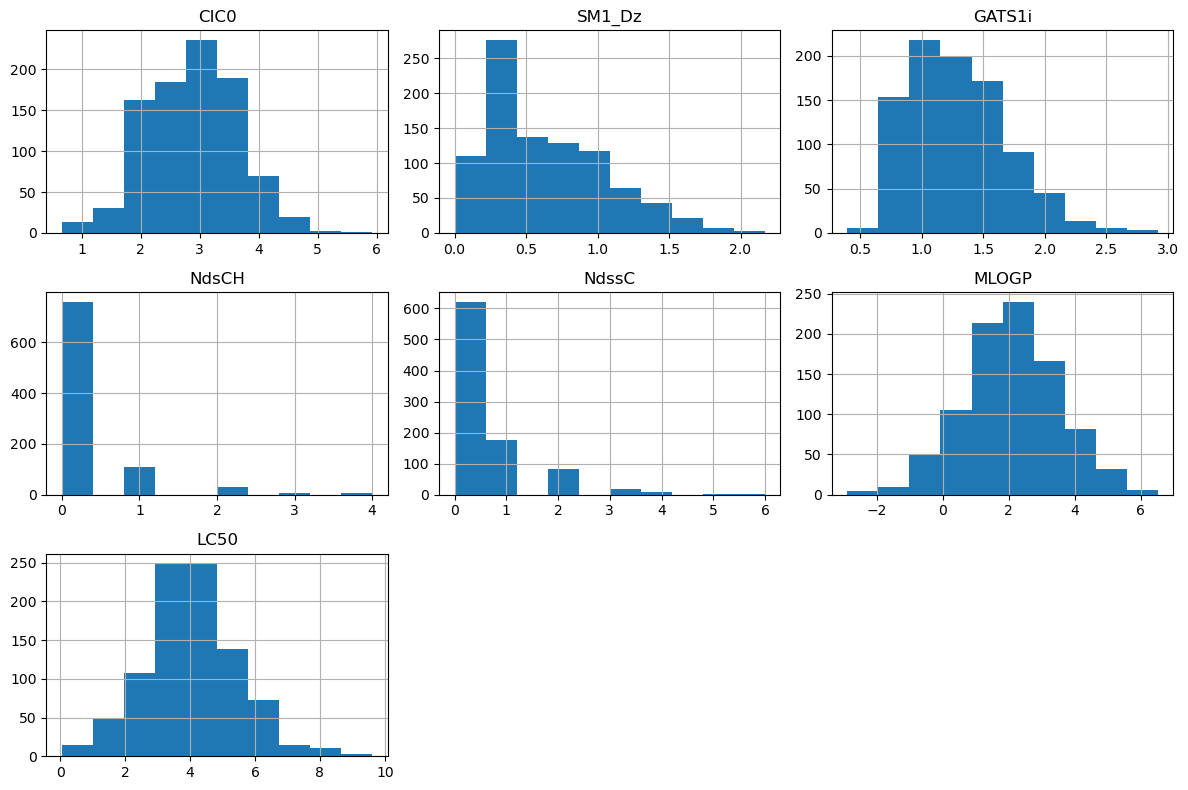

In [28]:
# plotting histograms for all columns
df.hist(figsize=(12,8))
plt.tight_layout()
plt.show()

In [29]:
df.skew()

CIC0      0.045458
SM1_Dz    0.695090
GATS1i    0.723107
NdsCH     3.400815
NdssC     2.239090
MLOGP    -0.035191
LC50      0.252138
dtype: float64

## Boxplots
Here I am using boxplots to visually check for 
outliers in each column.

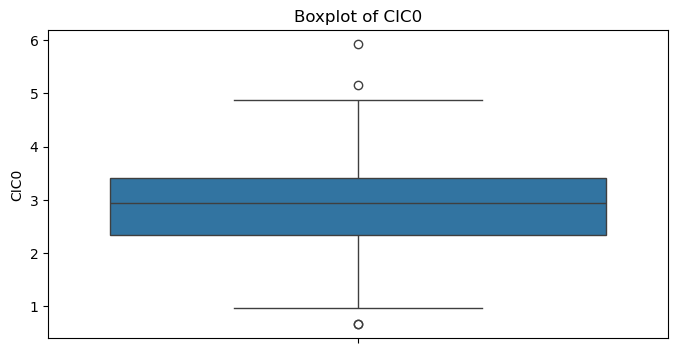

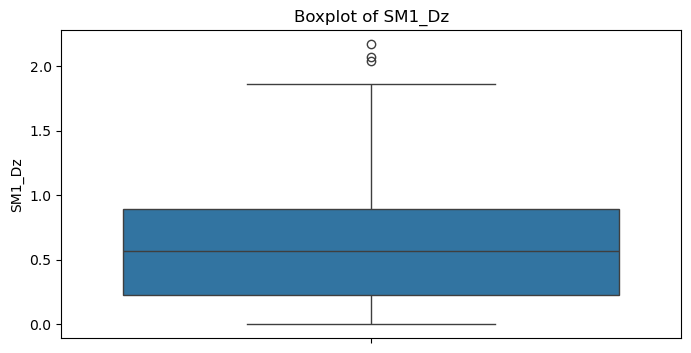

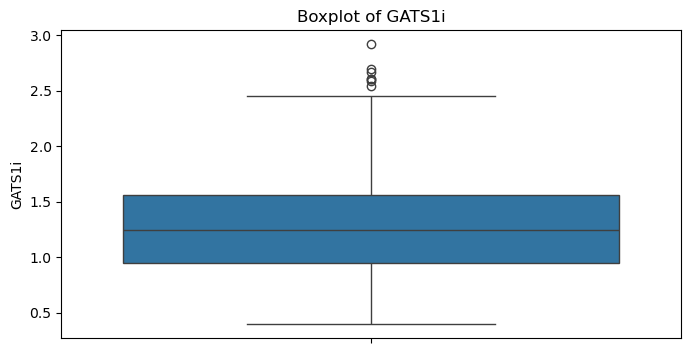

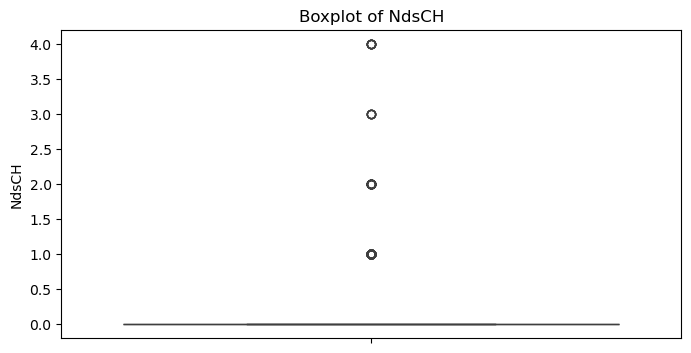

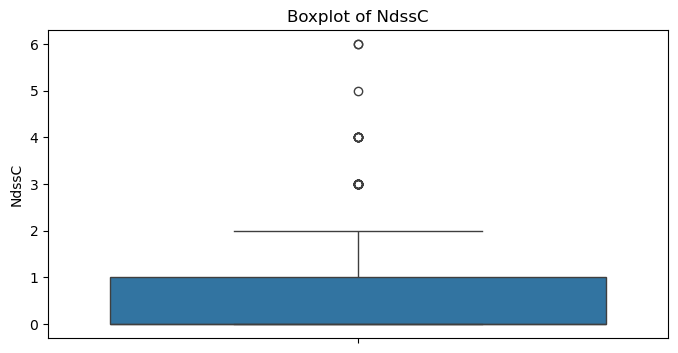

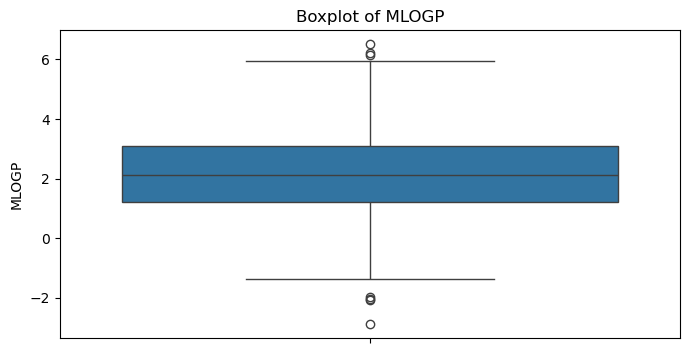

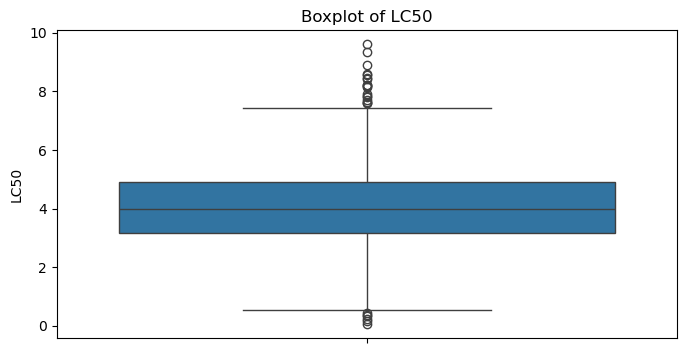

In [18]:
# creating boxplots for each column
# to check for outliers
for column in df.columns:
    plt.figure(figsize=(8,4))
    sns.boxplot(df[column])
    plt.title(f'Boxplot of {column}')
    plt.show()

## Detecting Outliers with Z Score
Here I am using the Z Score method to detect 
outliers. The Z Score measures how many standard 
deviations a value is from the mean. Any value 
with a Z Score above 3 is considered an outlier 
because it is too far from the average.

In [30]:
z_scores = np.abs(stats.zscore(df))
# counting how many outliers exist per column
# anything with z score above 3 is an outlier
print('Outliers detected per column:')
print((z_scores > 3).sum())

Outliers detected per column:
43


## Feature Target Relationships
Here I am looking at the relationship between 
each feature and our target variable LC50 to 
see which features might be most useful for 
building the model.

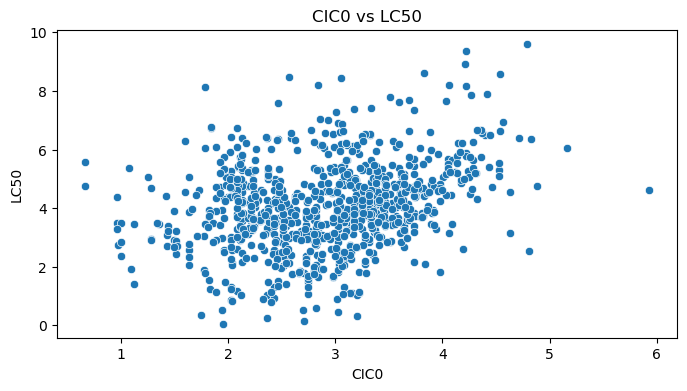

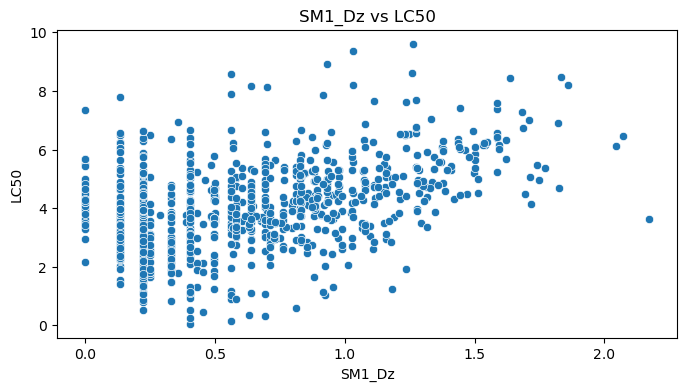

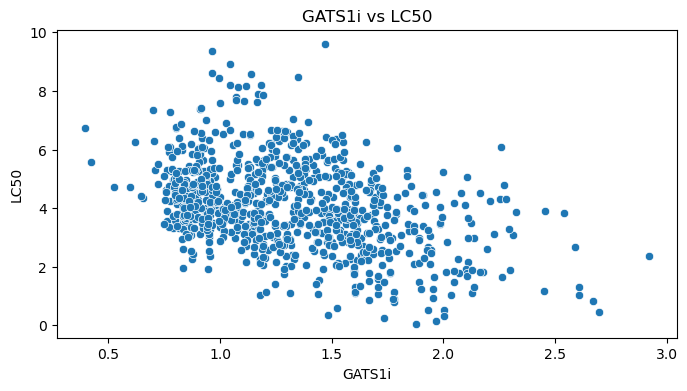

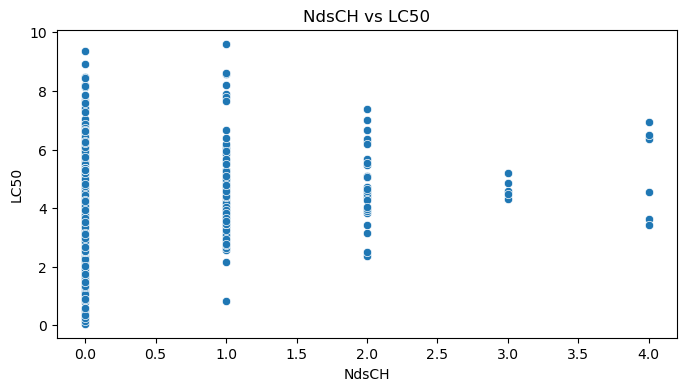

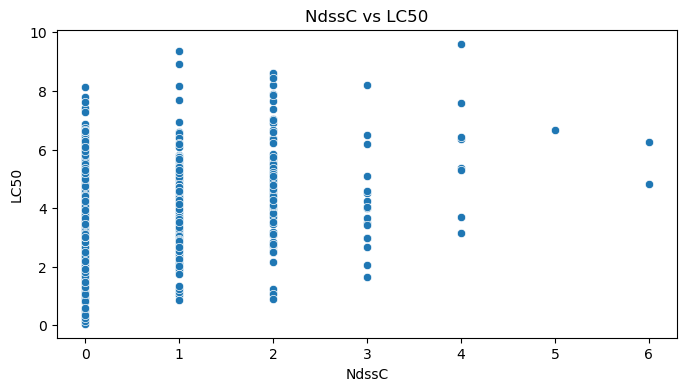

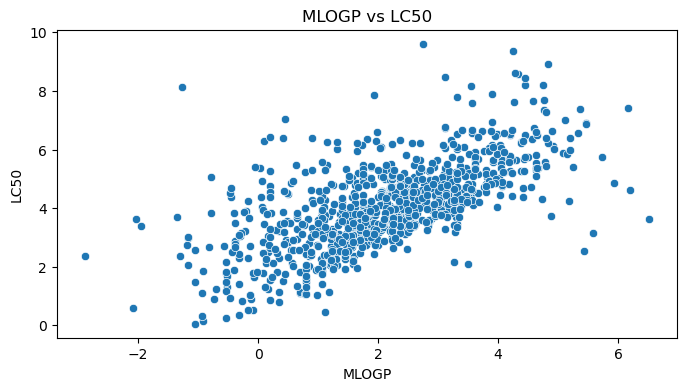

In [22]:
# plotting scatter plots of each feature vs LC50
# to see if there are any linear relationships
for column in ['CIC0', 'SM1_Dz', 'GATS1i', 'NdsCH', 'NdssC', 'MLOGP']:
    plt.figure(figsize=(8,4))
    sns.scatterplot(x=column, y='LC50', data=df)
    plt.title(f'{column} vs LC50')
    plt.show()

## Correlation Heatmap
Here I am checking the correlation between all 
the columns to see which features are most related 
to our target variable LC50. This will help me 
understand which features will be most useful 
for building the model.

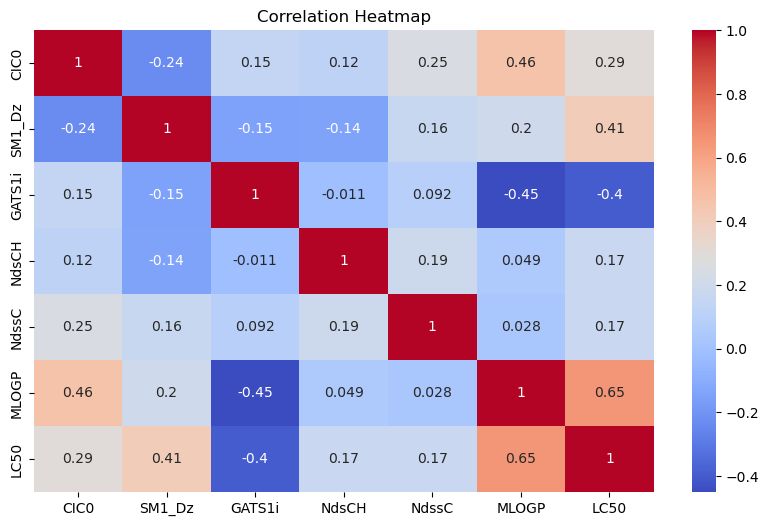

In [23]:
# creating a heatmap of correlations between all columns
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

## Multicollinearity Check
Here I am checking for multicollinearity between 
the features. Multicollinearity is when two or more 
features are highly correlated with each other which 
can negatively affect our model.

In [24]:
# checking correlation of each feature with LC50
# sorted from highest to lowest
df.corr()['LC50'].sort_values(ascending=False)

LC50      1.000000
MLOGP     0.651664
SM1_Dz    0.410893
CIC0      0.291854
NdssC     0.172390
NdsCH     0.172004
GATS1i   -0.397965
Name: LC50, dtype: float64

## Pairplot
Here I am creating a pairplot to visualize the 
relationships between all columns at once.


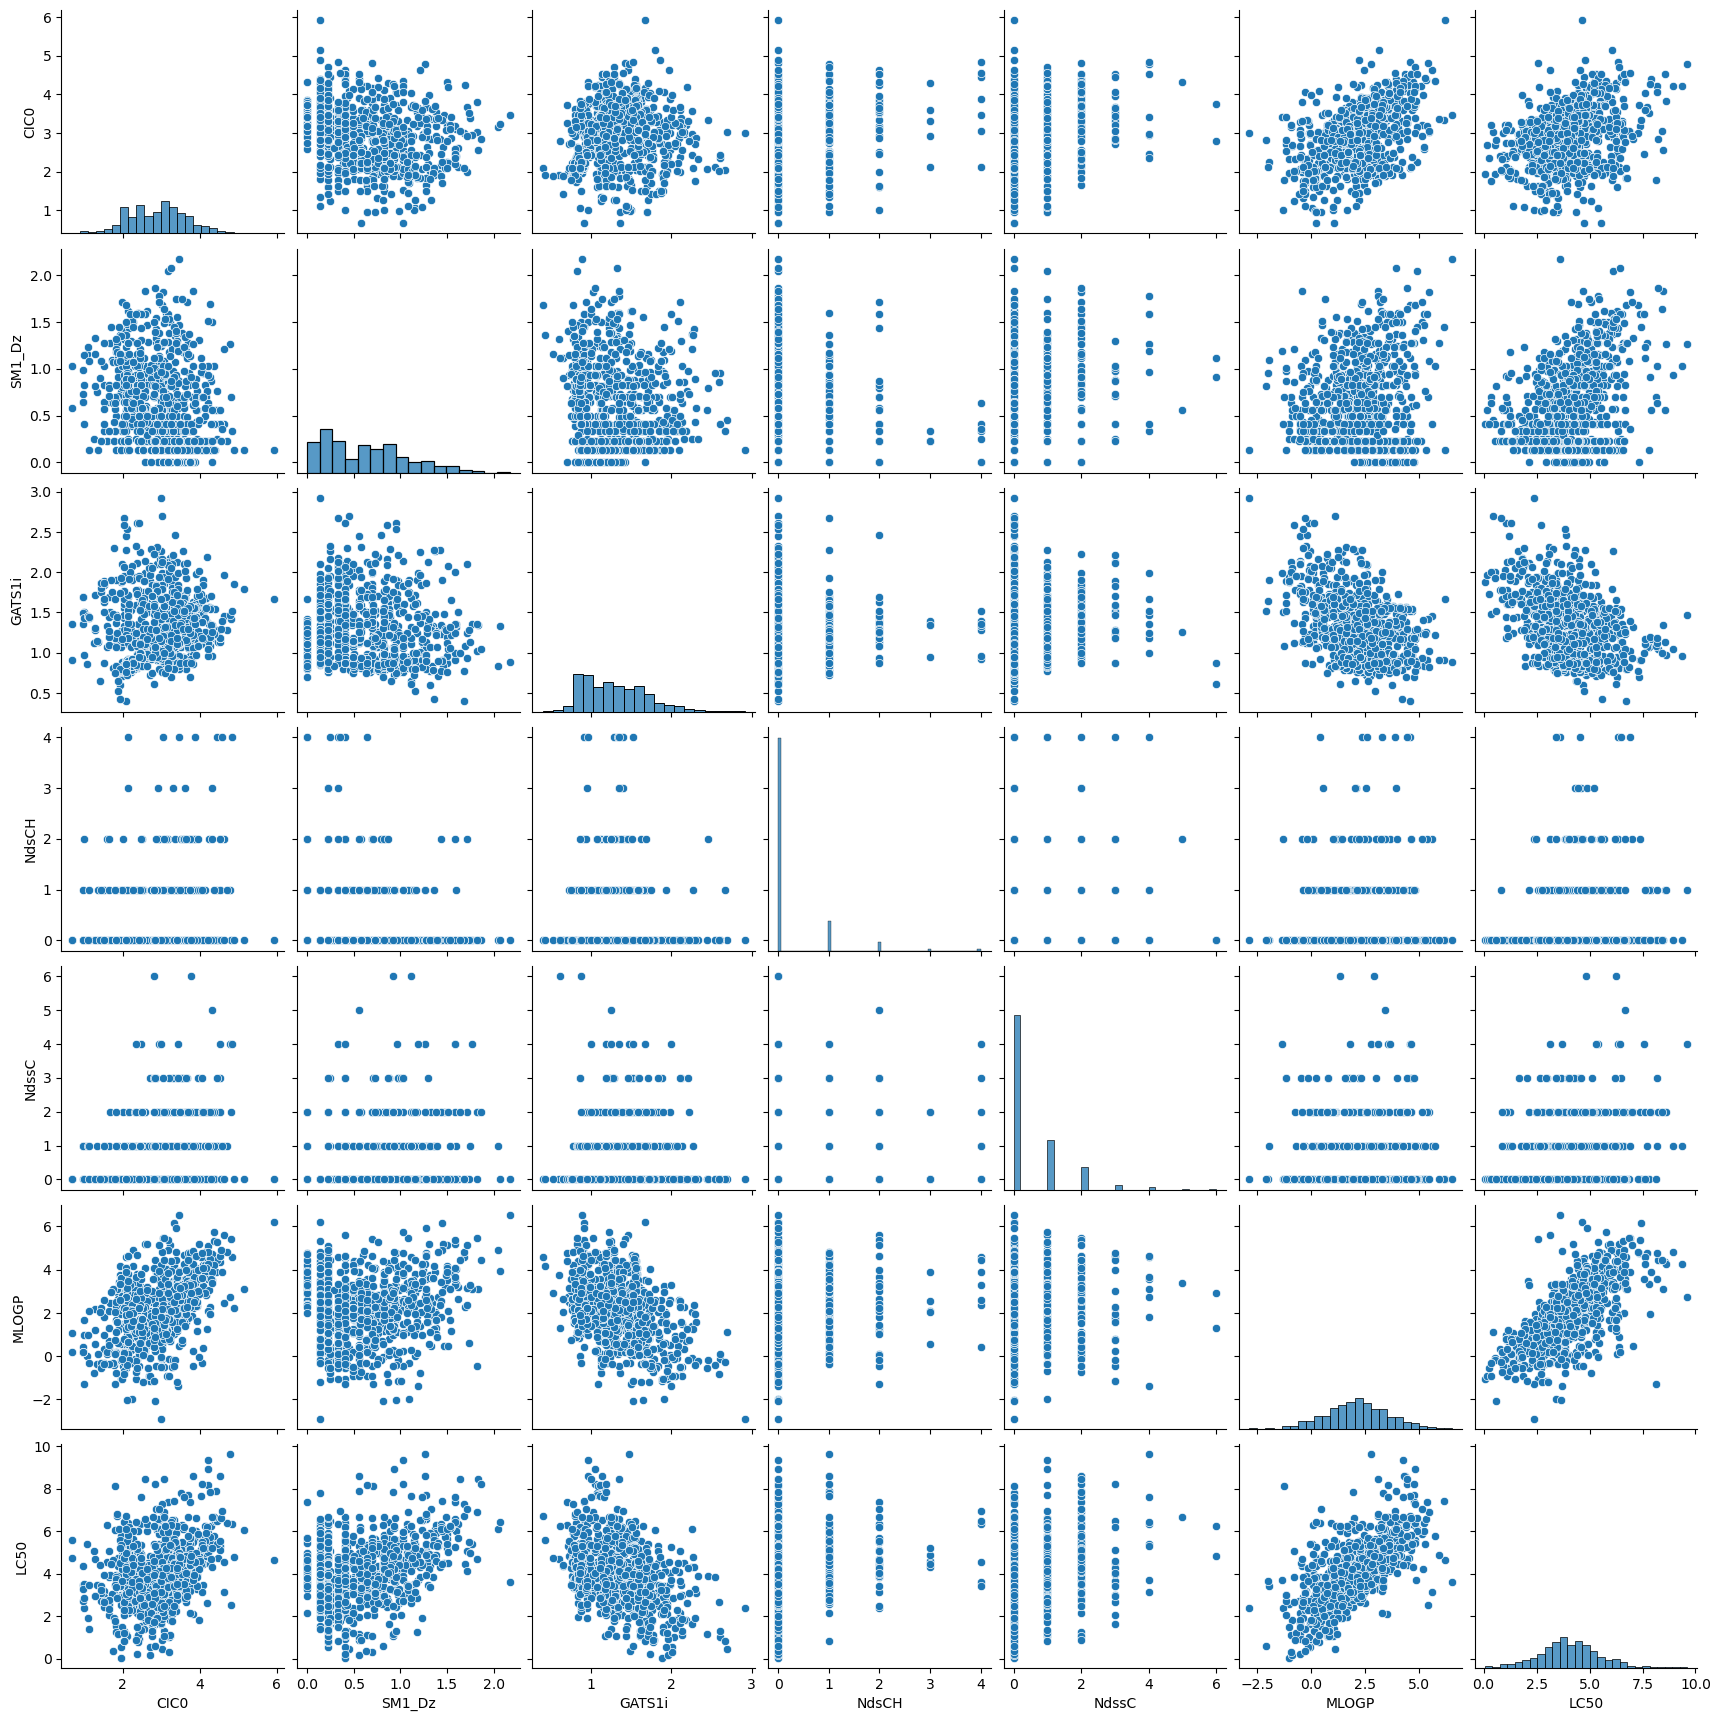

In [25]:
# pairplot shows relationships between all columns
sns.pairplot(df)
plt.show()

## Conclusions
- MLOGP has strongest correlation with LC50 (0.65)
- SM1_Dz and GATS1i have moderate correlations
- NdsCH and NdssC have weak correlations
- No multicollinearity detected between features
- All features will be kept for modeling